In [2]:
# LOAD LIBRARIES.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

### Numerical Simulation of Dyson Brownian Motion
---


Here the simulation of Dyson Brownian motion (DBM) is done in XXX steps.

1. Determine the system hyperparameters.
    - Dimension `N`, number of independent trials `M`, timestep `dt`, Dyson index `beta`, final time `T`, and the `potential_name` (supported "quadratic", "quad-quartic", "quartic").

2. Initialise the particles, e.g. at GUE equilibrium or according to a standard normal variable (see `random_matrix.py`).

3. Choose an algorithm and build the corresponding simulation pipeline. All algorithms use `N`, `dt`, `potential_name`, `beta`, with IMLA accepting `metropolise` (bool) and both implicit algorithms accepting `newton_tol` (float, default 1e-5).

4. Run the trajectories using `simulate.simulate_dbm(init, total_steps, pipeline)`.

5. Analyse the trajectory using `simulate.analyse_trajectory()`. This takes the trajectory object, the total number of steps, and a config dictionary.
    - For trajectory snapshots (e.g. for histogram) provide `burn_in`, defaults to half the total steps, and `snapshot_interval`, defaults to every ten steps.
    - For tracking acceptance rate, use `track_accepts = True`.
    - For tracking eigenvalue crossings, use `track_crossings = True` and provide the time step to evaluate at with `step_star`.
    - For tracking distance from true cdf, use `track_distance = True`, provide `F_exact` (see `densities.py`), the `grid` the cdf is evaluated on, and `dt`. Optionally use `distance_interval` and `distance_type`.

---

An example using MAIMLA is as below.

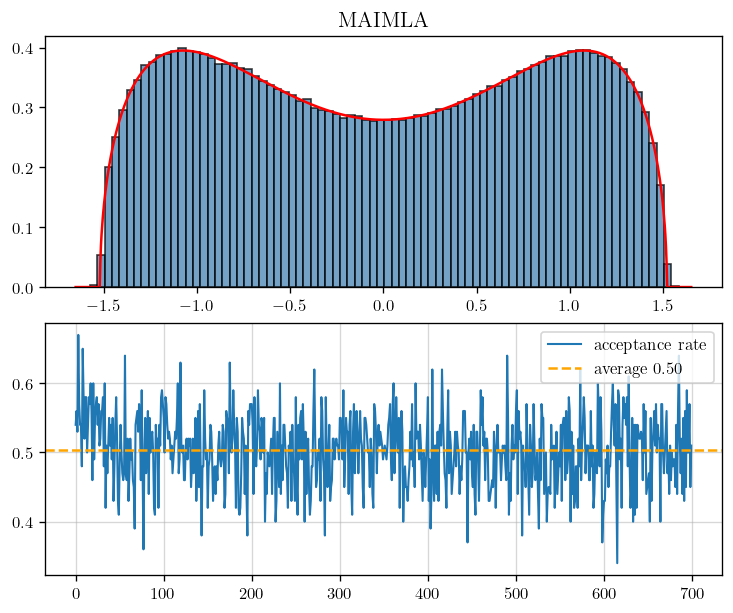

Mean Newton iterations: 5.21
Mean CG iterations: 8.88
Mean rejects due to line search failure: 0.14


In [3]:
# MAIMLA EXAMPLE.
# Set hyperparameters.
N = 70; dt = 1/N; beta = 2.0; T = 10.0;
M = 100; potential_name = "quartic"
total_steps = int(T/dt)

# Initialise at GUE equilibrium, for example (semicircle).
init = random_matrix.init_gue_eigenvalues(M, N)

# Build a MAIMLA pipeline and get trajectory generator.
maimla_pipe = simulate.make_imla_pipeline(N, dt, potential_name, beta, metropolise = True)
trajectory = simulate.simulate_dbm(init, total_steps, maimla_pipe)

# Decide on experiment configuration and call the observe function in `simulate.py`.
config = {
    "burn_in": int(3.0/dt), # Collect snapshots after T = 3. 
    "snapshot_interval": 5,
    "track_accepts": True,
    "track_newton_info": True # Also includes CG iterations and line search rejects.
}

info = simulate.analyse_trajectory(trajectory, total_steps, **config)

# Example plots for snapshots and acceptance rates.
fig, axes = plt.subplots(2, 1, figsize = (6, 5))
ax, ax2 = axes

plotters.plot_hist(ax, info["snapshots"], num_bins = 80, potential_name = potential_name)
plotters.plot_accepts(ax2, info["accepts"])

ax.grid(False)
ax.set_title(f"MAIMLA")

plt.show()

print(f"Mean Newton iterations: {info["newton_iters"].mean():.2f}")
print(f"Mean CG iterations: {info["mean_cg_iters"].mean():.2f}")
print(f"Mean rejects due to line search failure: {info["line_search_rejects"].mean():.2f}")